In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt


dataset_path = input("/content/wdbc.data")


try:
    df = pd.read_csv(dataset_path, header=None)
except FileNotFoundError:
    print(f"Error: The file at '{dataset_path}' was not found. Please check the path and try again.")
    exit()
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    exit()

df = df.drop(0, axis=1)

if df.shape[1] == 32:
    if df[32].isnull().all():
        df = df.drop(32, axis=1)

y = df[1].map({'M': 1, 'B': 0})
X = df.drop(1, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Dataset loaded and split successfully.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

/content/wdbc.data/content/wdbc.data
Dataset loaded and split successfully.
Training set size: 398 samples
Testing set size: 171 samples


In [5]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [6]:
# Train a Naïve Bayes classifier on the training data
model = GaussianNB()
model.fit(X_train, y_train)

print("Naïve Bayes model trained successfully.")

Naïve Bayes model trained successfully.


In [7]:
# Predict class labels for the test data
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (Malignant)

# Evaluate the model
print("\n--- Model Evaluation ---")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'])
print("\nClassification Report:")
print(class_report)


--- Model Evaluation ---
Accuracy: 0.9357

Confusion Matrix:
[[106   1]
 [ 10  54]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.99      0.95       107
   Malignant       0.98      0.84      0.91        64

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



<Figure size 800x600 with 0 Axes>

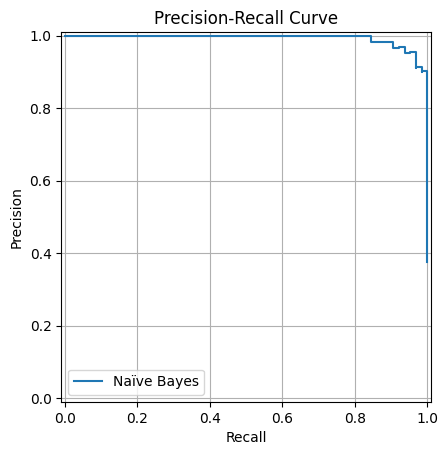


Evaluation complete. Precision-Recall Curve displayed.


In [8]:
# Precision-Recall Curve
plt.figure(figsize=(8, 6))
prec, recall, _ = precision_recall_curve(y_test, y_proba)
display = PrecisionRecallDisplay(precision=prec, recall=recall, estimator_name="Naïve Bayes")
display.plot()
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

print("\nEvaluation complete. Precision-Recall Curve displayed.")

In [9]:
# Train a Naïve Bayes classifier on the training data
model = GaussianNB()
model.fit(X_train, y_train)

print("Naïve Bayes model trained successfully.")

Naïve Bayes model trained successfully.


In [10]:
# Predict class labels for the test data
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (Malignant)

# Evaluate the model
print("\n--- Model Evaluation ---")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'])
print("\nClassification Report:")
print(class_report)


--- Model Evaluation ---
Accuracy: 0.9357

Confusion Matrix:
[[106   1]
 [ 10  54]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.99      0.95       107
   Malignant       0.98      0.84      0.91        64

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



<Figure size 800x600 with 0 Axes>

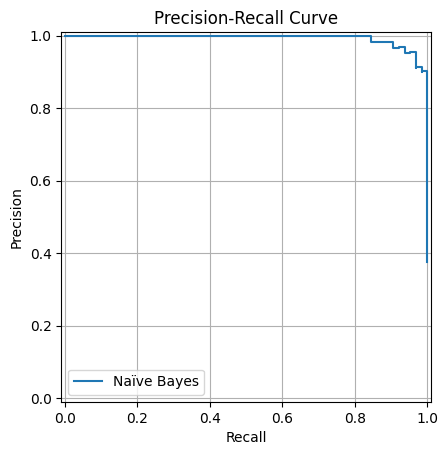


Evaluation complete. Precision-Recall Curve displayed.


In [11]:
# Precision-Recall Curve
plt.figure(figsize=(8, 6))
prec, recall, _ = precision_recall_curve(y_test, y_proba)
display = PrecisionRecallDisplay(precision=prec, recall=recall, estimator_name="Naïve Bayes")
display.plot()
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

print("\nEvaluation complete. Precision-Recall Curve displayed.")